# Event Clustering

For each `(position group, logical event type)` pair fit by
`archetypes.event_clustering`, this notebook:

1. Loads the fitted `StandardScaler -> MiniBatchKMeans` pipeline.
2. Re-applies it to a sample of the underlying events.
3. Plots the events on a pitch, colored by cluster, so you can
   eyeball what each cluster represents (e.g. short build-up
   passes vs. long switches; box-edge shots vs. far-out shots).

In [24]:
from __future__ import annotations
import sys
from pathlib import Path

# locate repo root from the notebook's location
HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / "configs" / "config.yaml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

CFG = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
ART = ROOT / CFG["data_paths"]["archetype_artifacts"]
EVENT_MODEL_DIR = ART / "event_clusters"
ARCH_MODEL_DIR = ART / "archetype_clusters"

EVENT_TYPES_PER_GROUP = CFG["event_clustering"]["event_types_per_group"]
N_CLUSTERS_PER_EVENT = CFG["event_clustering"]["n_clusters_per_event"]
N_ARCHETYPES_PER_GROUP = CFG["archetype_clustering"]["n_archetypes_per_group"]
POSITION_GROUPS = list(EVENT_TYPES_PER_GROUP.keys())

print("ROOT:", ROOT)
print("ART :", ART)

ROOT: c:\Users\zcoch\dsc_148\DSC 148 Final Project
ART : c:\Users\zcoch\dsc_148\DSC 148 Final Project\data\processed\archetype_artifacts


In [25]:
from mplsoccer import Pitch

# Wyscout export in this project is rescaled to StatsBomb 120 x 80.
PITCH = Pitch(pitch_type="statsbomb", line_color="white", pitch_color="#0e3a1f")

## Load events and re-attach `position_group` + `logical_event_type`

We only need the columns the cluster models were fit on, plus the
two label columns the orchestrator computes.

In [26]:
from archetypes.event_clustering import (
    load_event_clusters, predict_event_clusters,
    _FEATURE_BUILDERS,
)
from archetypes.run_pipeline import EVENT_COLUMNS, prepare_events

events = pd.read_parquet(ROOT / "data" / "raw" / "all_events.parquet",
                         columns=EVENT_COLUMNS)
events = prepare_events(events)

models = load_event_clusters(EVENT_MODEL_DIR)
print(f"loaded {len(models)} event-cluster models")

[prep] assigning position_group + logical_event_type
[prep] dropped 21,230 passes with end at (0, 0)
[prep] retained 8,810,054 rows after group/type filter
       group counts:
position_group
CM     2447662
CD     1975601
CF     1027167
LWD     869258
RWD     850459
LWP     655663
RWP     648288
GK      335956
       logical_event_type counts:
logical_event_type
pass               5722859
offensive_duel     1121034
defensive_duel     1109012
aerial_duel         660617
shot                167943
goalkeeper_exit      28589
loaded 37 event-cluster models


## Plot helper

For passes we draw start->end arrows; for everything else just the
start location. We sample ~1500 events per panel so plots stay
readable.

In [27]:
CLUSTER_PALETTE = plt.get_cmap("tab10")

def plot_event_clusters(group, event_type, ax, n_sample=1500):
    if (group, event_type) not in models:
        ax.set_visible(False)
        return
    sub = events[(events["position_group"] == group)
                 & (events["logical_event_type"] == event_type)]
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=0)
    labels = predict_event_clusters(sub, models[(group, event_type)], event_type)
    PITCH.draw(ax=ax)
    for c in sorted(set(labels)):
        if c == -1:
            continue
        m = labels == c
        color = CLUSTER_PALETTE(c % 10)
        if event_type == "pass":
            PITCH.lines(
                sub.loc[m, "start_x"], sub.loc[m, "start_y"],
                sub.loc[m, "end_x"],   sub.loc[m, "end_y"],
                ax=ax, color=color, alpha=0.35, lw=0.7,
                comet=False,
            )
        else:
            PITCH.scatter(
                sub.loc[m, "start_x"], sub.loc[m, "start_y"],
                ax=ax, s=10, color=color, alpha=0.55, edgecolors="none",
            )
    ax.set_title(f"{group} / {event_type} (n={len(sub)})", color="white",
                 fontsize=9, pad=4)

## One figure per position group

Each row of subplots = the event types used by that group.

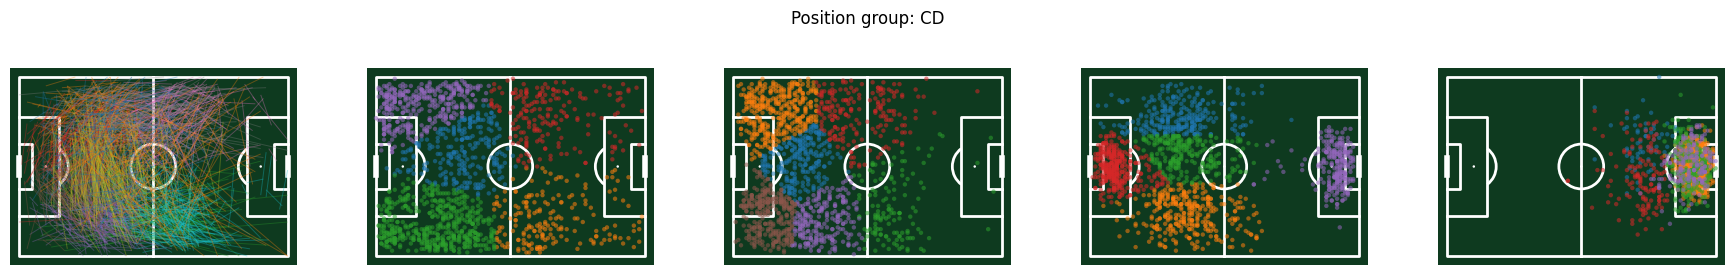

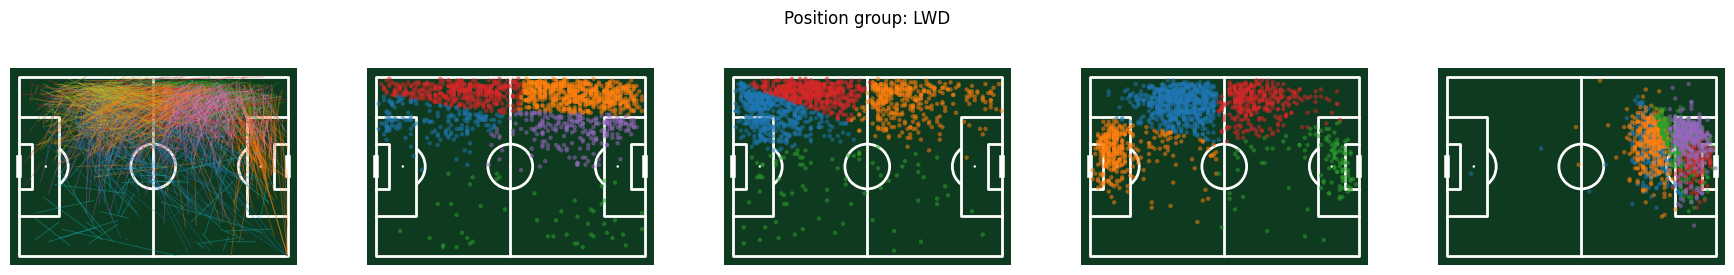

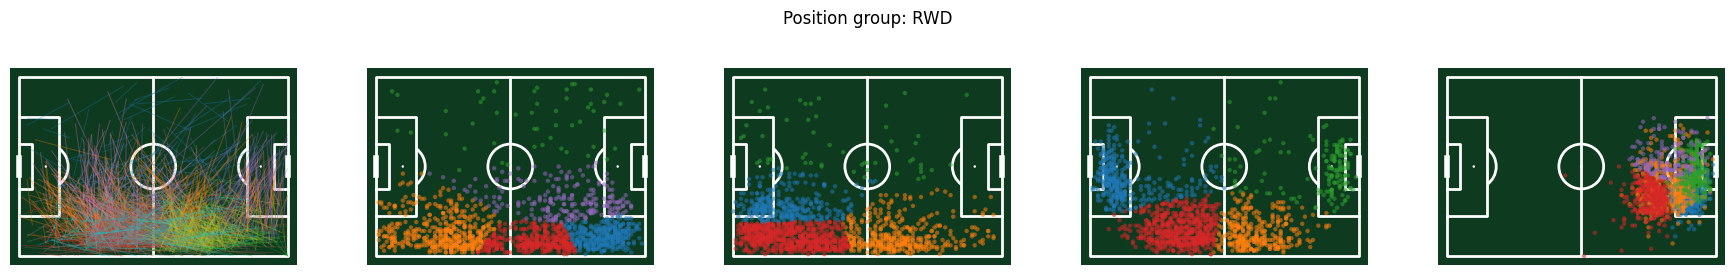

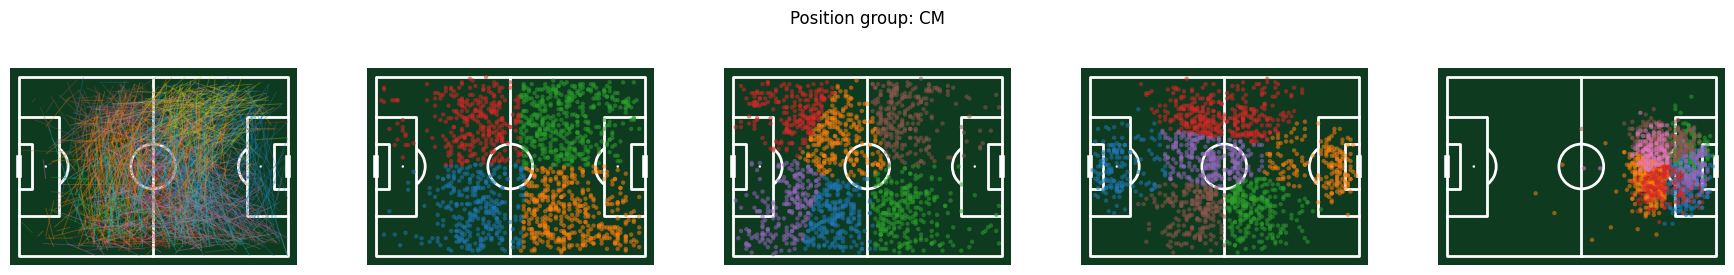

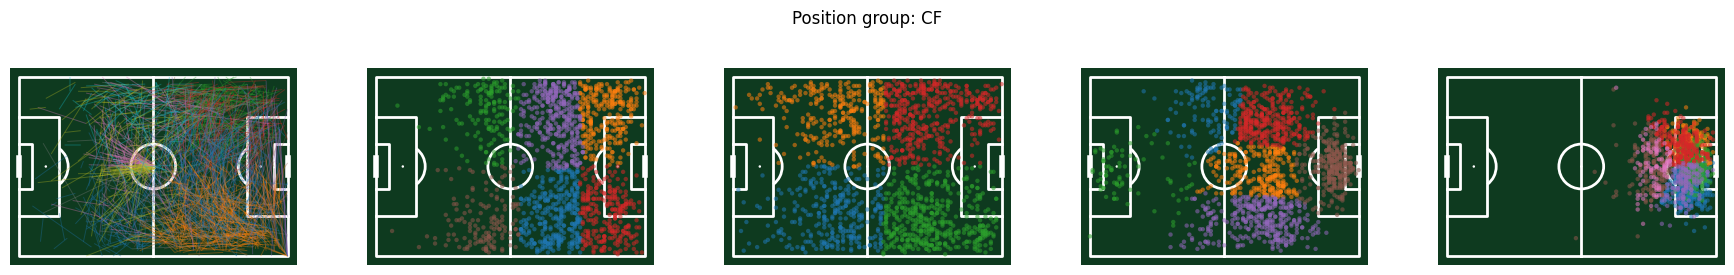

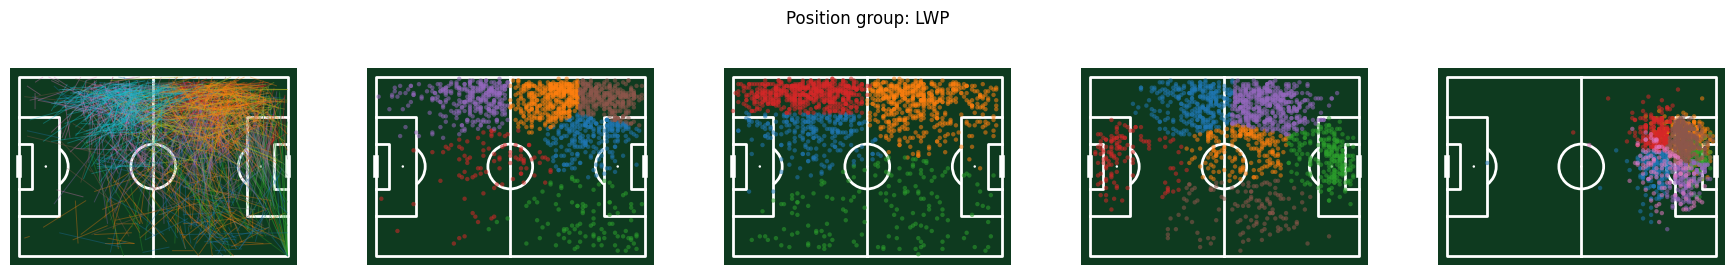

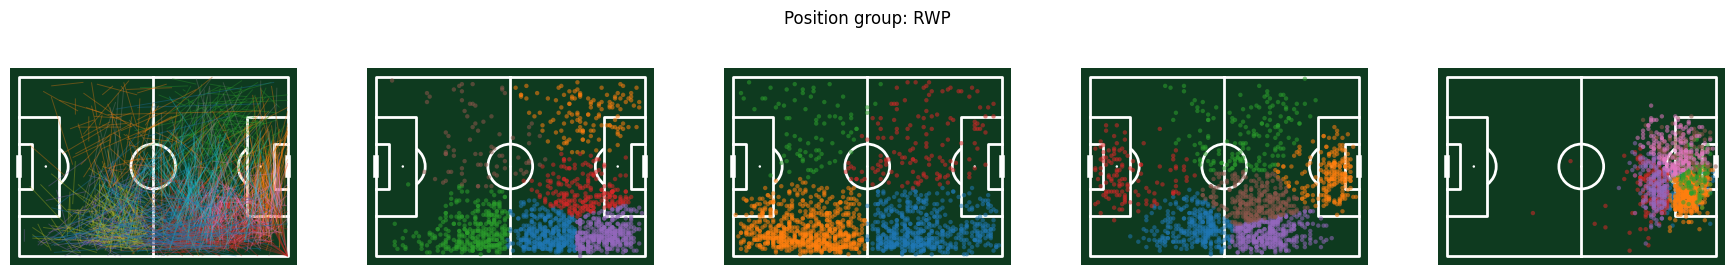

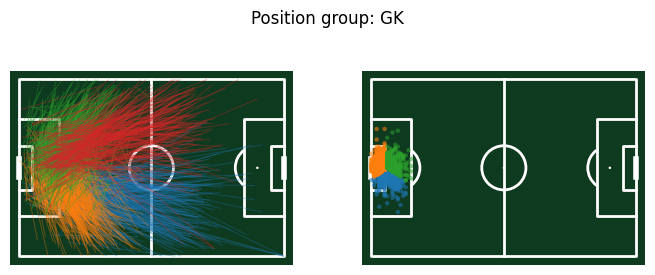

In [28]:
for group in POSITION_GROUPS:
    ets = EVENT_TYPES_PER_GROUP[group]
    fig, axes = plt.subplots(1, len(ets), figsize=(3.6 * len(ets), 2.6))
    if len(ets) == 1:
        axes = [axes]
    for ax, et in zip(axes, ets):
        plot_event_clusters(group, et, ax)
    fig.suptitle(f"Position group: {group}", y=1.04, fontsize=12)
    fig.tight_layout()
    plt.show()

## Per-cluster feature means

For each `(group, event_type)`, the mean of every feature column
inside each cluster. This is the textual companion to the pitch
plots above — useful for labeling clusters as "short progressive
pass" vs. "long diagonal switch", etc.

In [20]:
def cluster_feature_means(group, event_type, n_sample=20000):
    model = models[(group, event_type)]
    sub = events[(events["position_group"] == group)
                 & (events["logical_event_type"] == event_type)]
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=0)
    feats = _FEATURE_BUILDERS[event_type](sub)
    feats = feats[model["feature_cols"]].dropna()
    labels = model["pipeline"].predict(feats.values)
    df = feats.assign(cluster=labels)
    return df.groupby("cluster").mean().round(3)

for group in POSITION_GROUPS:
    for et in EVENT_TYPES_PER_GROUP[group]:
        if (group, et) in models:
            print(f"--- {group} / {et} ---")
            print(cluster_feature_means(group, et))
            print()

--- CD / pass ---
         start_x  start_y   end_x   end_y  length    angle  delta_x  \
cluster                                                               
0         40.689   49.143  46.829  19.212  27.363  -78.068    6.139   
1         30.126   21.882  42.339  16.370  14.827  -24.053   12.213   
2         34.686   61.062  81.191  62.597  42.231    1.880   46.505   
3         36.319   21.408  26.899  38.799  18.895  117.929   -9.420   
4         30.432   58.251  42.831  64.542  15.234   27.082   12.398   
5         36.257   59.058  27.135  41.582  18.934 -116.955   -9.122   
6         64.581   20.287  78.571  18.407  17.334   -1.628   13.990   
7         34.785   18.731  82.266  17.340  43.074   -1.601   47.481   
8         39.923   28.573  45.302  60.068  28.504   79.960    5.379   
9         65.639   59.522  79.756  61.730  17.576    3.005   14.118   
10        37.079   32.326  52.943  30.344  17.473   -6.979   15.863   
11        51.015   42.432  89.662  37.282  48.911   -7.046 

## k-sweep: elbow + silhouette per `(group, event_type)`

Fits MiniBatchKMeans for `k` in `2..12` for every `(group,
event_type)` pair on a sample of events and reports both the
inertia (elbow) and silhouette score. The vertical red dashed
line marks the `k` currently set in
`configs/config.yaml::n_clusters_per_event[group][event_type]`.

Use the plots to retune that config value. Runtime is a few
minutes on the full dataset — the sample sizes below trade
accuracy for speed.

In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

K_SWEEP = list(range(2, 13))
SAMPLE_FOR_FIT = 30_000
SAMPLE_FOR_SILHOUETTE = 5_000

def sweep_event_k(group, event_type):
    sub = events[(events["position_group"] == group)
                 & (events["logical_event_type"] == event_type)]
    feats_df = _FEATURE_BUILDERS[event_type](sub).dropna()
    if len(feats_df) < max(K_SWEEP) + 1:
        return None
    if len(feats_df) > SAMPLE_FOR_FIT:
        feats_df = feats_df.sample(SAMPLE_FOR_FIT, random_state=0)
    X = StandardScaler().fit_transform(feats_df.values)
    silh_idx = np.random.RandomState(0).choice(
        len(X), size=min(SAMPLE_FOR_SILHOUETTE, len(X)), replace=False)
    X_silh = X[silh_idx]
    inertias, silhs = [], []
    for k in K_SWEEP:
        km = MiniBatchKMeans(n_clusters=k, n_init=3, random_state=0,
                             batch_size=4096).fit(X)
        inertias.append(km.inertia_)
        silhs.append(silhouette_score(X_silh, km.predict(X_silh)))
    return inertias, silhs

sweep_results = {}
for group in POSITION_GROUPS:
    for et in EVENT_TYPES_PER_GROUP[group]:
        print(f"sweeping {group}/{et} ...", end=" ", flush=True)
        res = sweep_event_k(group, et)
        sweep_results[(group, et)] = res
        print("ok" if res else "skipped (too few events)")

sweeping CD/pass ... ok
sweeping CD/offensive_duel ... ok
sweeping CD/defensive_duel ... ok
sweeping CD/aerial_duel ... ok
sweeping CD/shot ... ok
sweeping LWD/pass ... ok
sweeping LWD/offensive_duel ... ok
sweeping LWD/defensive_duel ... ok
sweeping LWD/aerial_duel ... ok
sweeping LWD/shot ... ok
sweeping RWD/pass ... ok
sweeping RWD/offensive_duel ... ok
sweeping RWD/defensive_duel ... ok
sweeping RWD/aerial_duel ... ok
sweeping RWD/shot ... ok
sweeping CM/pass ... ok
sweeping CM/offensive_duel ... ok
sweeping CM/defensive_duel ... ok
sweeping CM/aerial_duel ... ok
sweeping CM/shot ... ok
sweeping CF/pass ... ok
sweeping CF/offensive_duel ... ok
sweeping CF/defensive_duel ... ok
sweeping CF/aerial_duel ... ok
sweeping CF/shot ... ok
sweeping LWP/pass ... ok
sweeping LWP/offensive_duel ... ok
sweeping LWP/defensive_duel ... ok
sweeping LWP/aerial_duel ... ok
sweeping LWP/shot ... ok
sweeping RWP/pass ... ok
sweeping RWP/offensive_duel ... ok
sweeping RWP/defensive_duel ... ok
sweeping

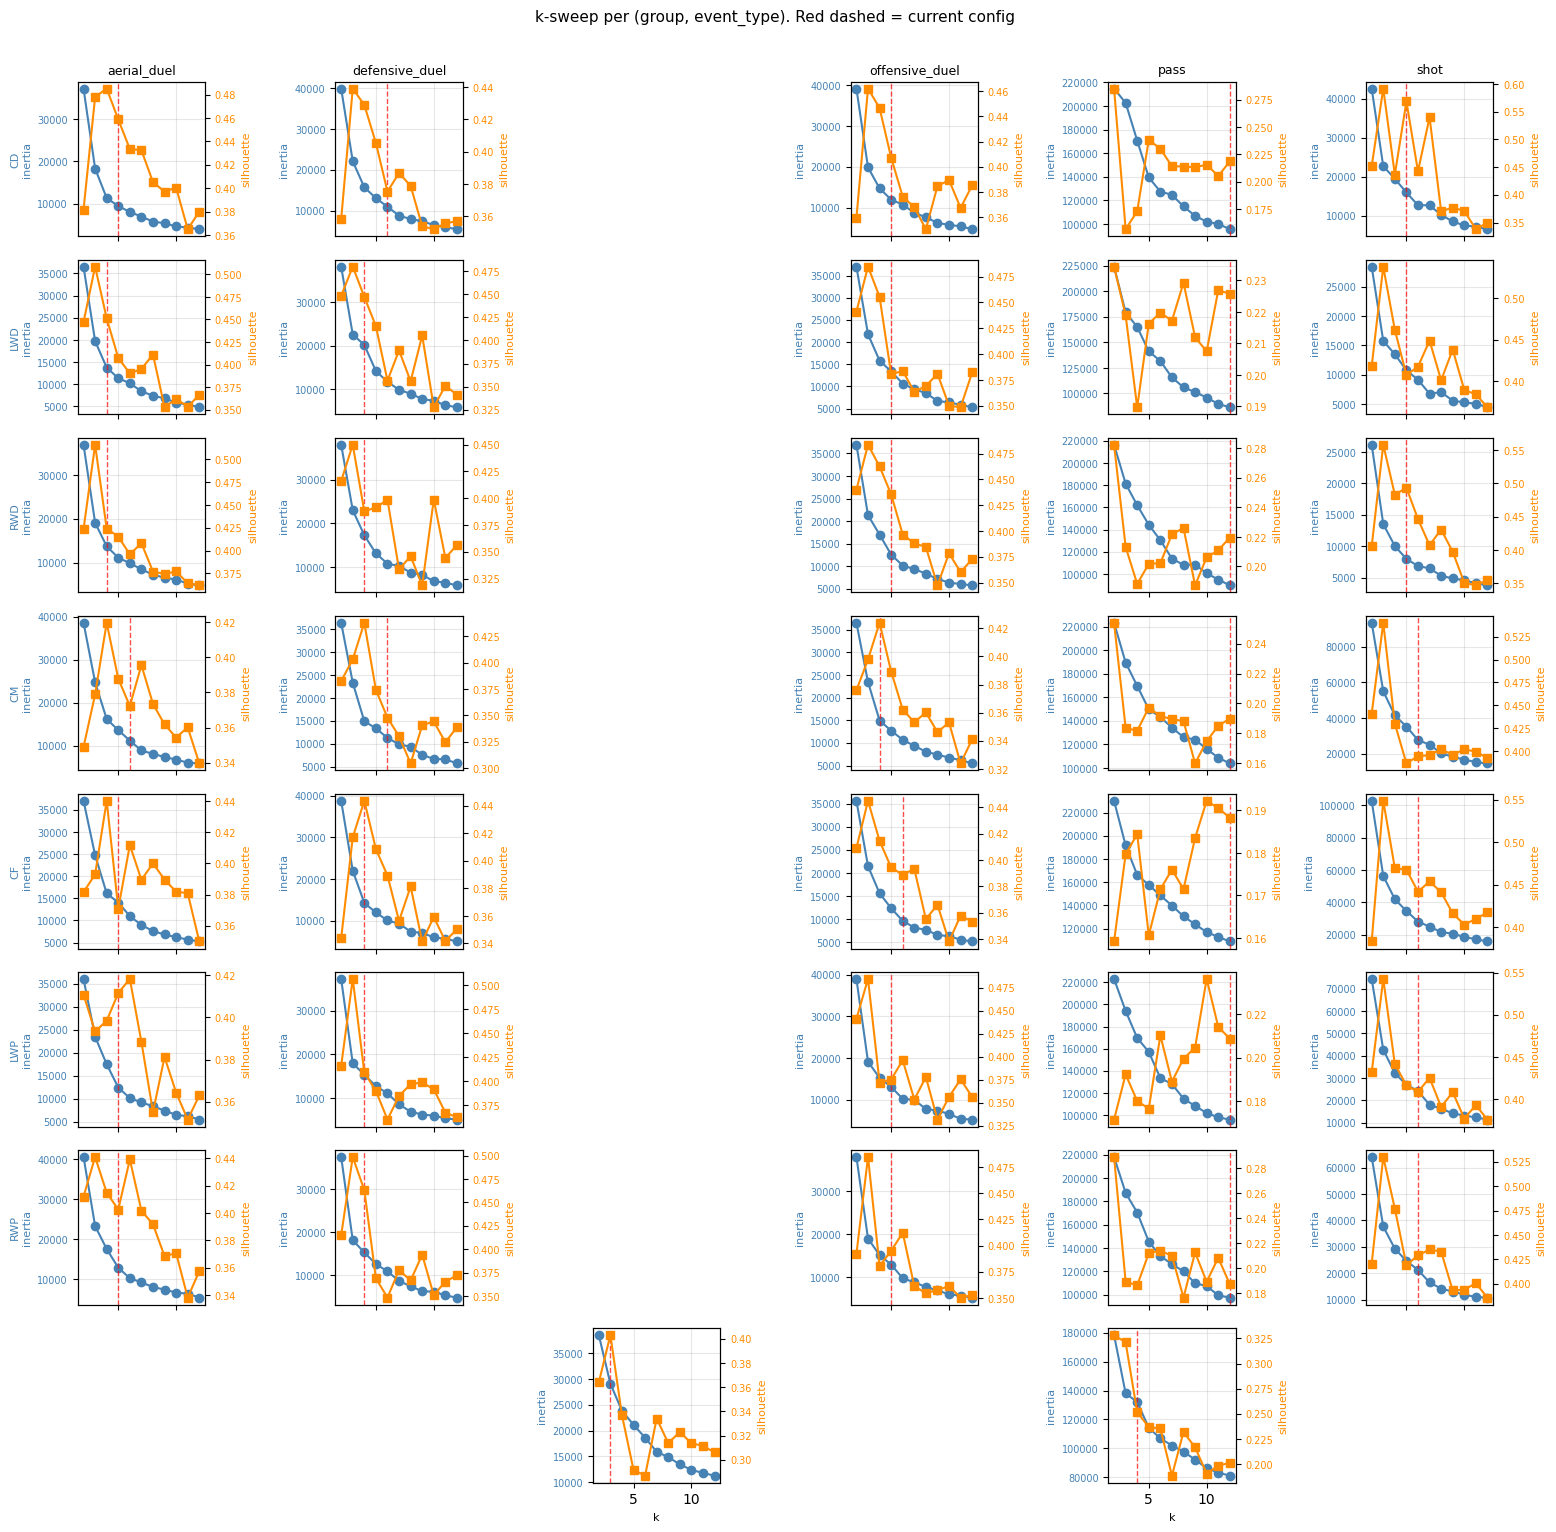

In [22]:
# Plot grid: rows = position group, cols = event type.
all_ets = sorted({et for ets in EVENT_TYPES_PER_GROUP.values() for et in ets})
nrows = len(POSITION_GROUPS)
ncols = len(all_ets)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 1.9 * nrows),
                         sharex=True)
for i, group in enumerate(POSITION_GROUPS):
    for j, et in enumerate(all_ets):
        ax = axes[i, j]
        res = sweep_results.get((group, et))
        if res is None or et not in EVENT_TYPES_PER_GROUP[group]:
            ax.set_visible(False)
            continue
        inertias, silhs = res
        ax.plot(K_SWEEP, inertias, marker="o", color="steelblue", label="inertia")
        ax.set_ylabel("inertia", color="steelblue", fontsize=8)
        ax.tick_params(axis="y", labelcolor="steelblue", labelsize=7)
        ax2 = ax.twinx()
        ax2.plot(K_SWEEP, silhs, marker="s", color="darkorange", label="silhouette")
        ax2.set_ylabel("silhouette", color="darkorange", fontsize=8)
        ax2.tick_params(axis="y", labelcolor="darkorange", labelsize=7)
        k_used = N_CLUSTERS_PER_EVENT[group][et]
        ax.axvline(k_used, color="red", lw=1, ls="--", alpha=0.7)
        if i == 0:
            ax.set_title(et, fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{group}\ninertia", color="steelblue", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("k", fontsize=8)
        ax.grid(alpha=0.3)
fig.suptitle("k-sweep per (group, event_type). Red dashed = current config",
             y=1.005, fontsize=11)
fig.tight_layout()
plt.show()

### Suggested k per pair (k that maximizes silhouette)

A purely silhouette-driven recommendation. Inertia elbows often
disagree with silhouette — use the plots above for the final
call.

In [23]:
rows = []
for (group, et), res in sweep_results.items():
    if res is None:
        continue
    _, silhs = res
    best_idx = int(np.argmax(silhs))
    rows.append({
        "group": group,
        "event_type": et,
        "k_current": N_CLUSTERS_PER_EVENT[group][et],
        "k_best_silhouette": K_SWEEP[best_idx],
        "silhouette_at_best": round(float(silhs[best_idx]), 3),
        "silhouette_at_current": round(float(
            silhs[K_SWEEP.index(N_CLUSTERS_PER_EVENT[group][et])]
            if N_CLUSTERS_PER_EVENT[group][et] in K_SWEEP else float("nan")), 3),
    })
pd.DataFrame(rows)

,group,event_type,k_current,k_best_silhouette,silhouette_at_best,silhouette_at_current
0,CD,pass,12,2,0.285,0.219
1,CD,offensive_duel,5,3,0.462,0.407
2,CD,defensive_duel,6,3,0.439,0.375
3,CD,aerial_duel,5,4,0.485,0.459
4,CD,shot,5,3,0.592,0.569
5,LWD,pass,12,2,0.234,0.226
6,LWD,offensive_duel,5,3,0.485,0.381
7,LWD,defensive_duel,4,3,0.480,0.447
8,LWD,aerial_duel,4,3,0.509,0.451
9,LWD,shot,5,3,0.539,0.407
